# Beat Timer v0.4 Evaluator

This notebook runs the audio-only predictor and then evaluates its output against an `.osu` map.

The `.osu` file is loaded only after prediction is complete. Its objects score grid accuracy; its red timing points measure agreement with the mapper's chosen segmentation.

Keep this notebook in the same directory as:

- `beattimer_core.py`
- `beattimer_evaluation.py`
- the MP3
- the `.osu` file

In [73]:
from pathlib import Path
import numpy as np
import importlib
import json

import beattimer_core as core
import beattimer_evaluation as evaluation_tools

In [74]:
# Reload after editing either module.
importlib.reload(core)
importlib.reload(evaluation_tools)

<module 'beattimer_evaluation' from 'c:\\Users\\Caue\\Desktop\\School\\Programming\\osu beattimer projec\\beattimer_evaluation.py'>

## Inputs

In [75]:
song_selection = "sakuzyo_that_day"

AUDIO_PATH = Path(f"songs\\{song_selection}\\song.mp3")
OSU_PATH = Path(f"songs\\{song_selection}\\song.osu")

ANALYSIS_SETTINGS = {
    "round_initial_bpm": 1,
    "use_local_tempo": True,
    "integer_section_bpm": True,
    "section_tolerance_ms": 6.0,
}

OBJECT_SUBDIVISIONS = (1, 2, 3, 4)
REDLINE_TIME_TOLERANCE_SECONDS = 0.300
DIAGNOSTIC_SHIFT_RANGE_MS = (-100.0, 100.0)
DIAGNOSTIC_SHIFT_STEP_MS = 0.5

## 1. Produce the MP3-only prediction

In [76]:
result = core.analyze_song(
    AUDIO_PATH,
    **ANALYSIS_SETTINGS,
)

core.print_analysis_summary(result)

File: songs\sakuzyo_that_day\song.mp3
Duration: 73.796 s
Sample rate: 44100 Hz
Hop length: 256 samples
Raw global BPM: 84.035912
Used global BPM: 84.0
Analysis mode: local tempo
Detected onset candidates: 91
Global-grid matched observations: 58
Global-grid median error: 4.870 ms
Global-grid 95% error: 22.686 ms
Valid local windows: 288
Timing sections: 1
  1: 0.000s–73.796s, BPM=84.0, windows=0, matches=58, 95%=23.043ms


## 2. Evaluate after prediction

In [77]:
evaluation = evaluation_tools.evaluate_against_osu(
    result,
    OSU_PATH,
    subdivisions=OBJECT_SUBDIVISIONS,
    redline_time_tolerance=REDLINE_TIME_TOLERANCE_SECONDS,
    shift_range_ms=DIAGNOSTIC_SHIFT_RANGE_MS,
    shift_step_ms=DIAGNOSTIC_SHIFT_STEP_MS,
)

evaluation_tools.print_evaluation_summary(evaluation)

.osu file: songs\sakuzyo_that_day\song.osu
Hit objects: 132
Mapped redlines: 28
Objects scored: 132 / 132

Raw median object error: 40.000 ms
Diagnostic global shift: -40.000 ms
Aligned median object error: 0.429 ms
Aligned p95 object error: 30.100 ms

Objects within  2 ms:  85.6%
Objects within  5 ms:  85.6%
Objects within 10 ms:  87.1%
Objects within 20 ms:  90.9%
Objects within 40 ms:  96.2%

Redline precision / recall / F1: 0.000 / 0.000 / 0.000


## 3. Plots

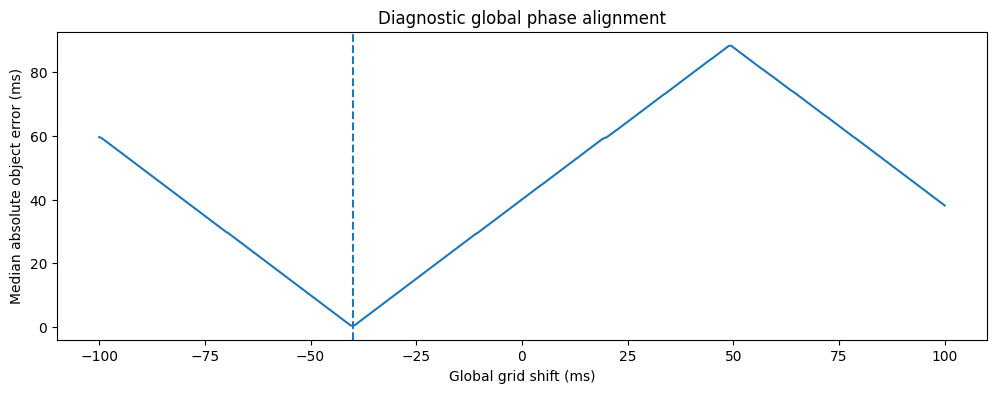

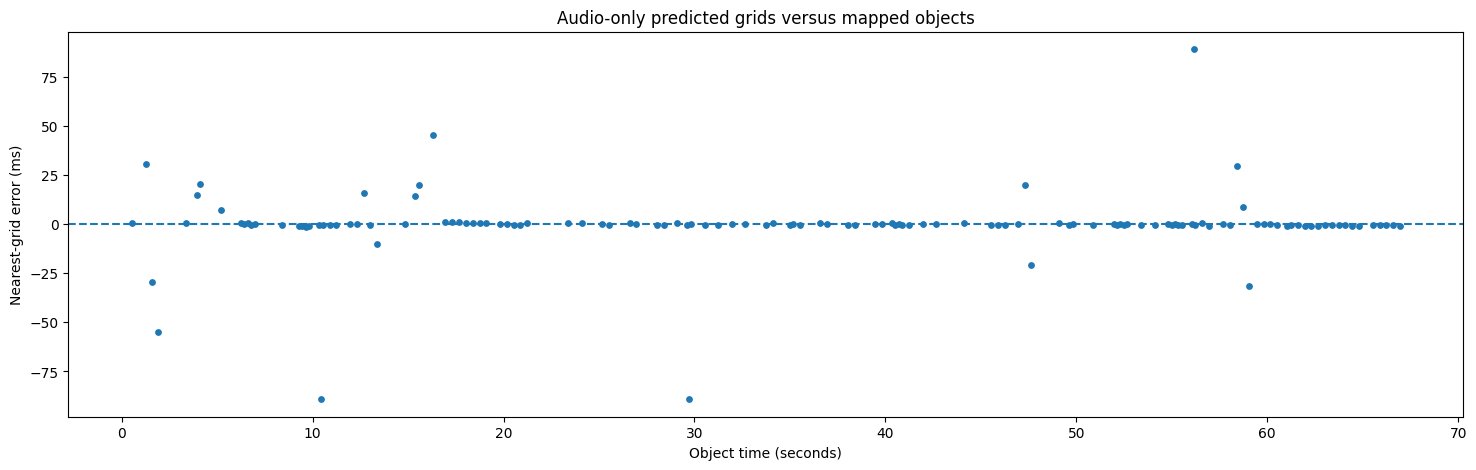

In [78]:
evaluation_tools.plot_evaluation(evaluation)

## 4. Per-section diagnostics

In [79]:
evaluation_tools.print_section_diagnostics(evaluation)

Section  0 |   0.00– 73.80s |  84.000 BPM | n=132 | median=  0.43 ms | p95= 30.10 ms | slope=  +0.06 ms/s | good


## 5. Optional prediction visualizer

In [80]:
figure = core.visualize_timing_segments(result)

## 6. Save a compact JSON benchmark

In [81]:
benchmark = {
    "audio_file": str(AUDIO_PATH),
    "osu_file": str(OSU_PATH),
    "global_bpm_raw": float(result["bpm_result"]["bpm"]),
    "global_bpm_used": float(result["initial_bpm"]),
    "timing_section_count": len(result["sections"]),
    "diagnostic_shift_ms": float(
        evaluation["shift_result"]["best_shift_ms"]
    ),
    "object_summary": evaluation["object_summary"],
    "redline_metrics": {
        key: evaluation["redline_comparison"][key]
        for key in (
            "true_positives",
            "false_positives",
            "false_negatives",
            "precision",
            "recall",
            "f1",
        )
    },
}

OUTPUT_PATH = Path("benchmark_dump\\benchmark_v0.4.json")
OUTPUT_PATH.write_text(
    json.dumps(benchmark, indent=2),
    encoding="utf-8",
)

print(f"Saved: {OUTPUT_PATH.resolve()}")

Saved: C:\Users\Caue\Desktop\School\Programming\osu beattimer projec\benchmark_dump\benchmark_v0.4.json
